## 1. Foreword

Your problem statement will be the guiding force that will influence every question and decision making from this point onward. Before starting any of the exercises get that down.

It would be helpful to refresh the basics of statistical modelling and machine learnin before proceeding, here are the essential concepts that you should understand:

1. Exploratory Data Analysis (EDA):
    - Descriptive statistics (mean, median, variance, quantiles)
    - Understanding distributions and variability 

2. Data Pre-processing
    - Features & Target Transformation
    - Creating new features
    - Feature Selection

3. Regression Models: Linear Regression, Regularized Regression (Ridge, Lasso)
    - Interpreting coefficients, understanding R², MSE, MAE, RMSE

4. Classification Models: Logistic Regression, Decision Trees, Random Forests, SVMs, K-Nearest Neighbors
    - Interpreting probabilities, coefficients (log-odds), and feature importances

5. Evaluation Metrics:
    - For Regression: R², Mean Squared Error (MSE), Mean Absolute Error (MAE), Root Mean Squared Error (RMSE)
    - For Classification: Accuracy, Precision, Recall, F1 Score, ROC-AUC, and Confusion Matrix

6. Model Selection & Validation:
    - Train-test splits, cross-validation techniques
    - Overfitting vs. underfitting
    - Hyperparameter tuning (grid search, random search)

7. Model Interpretability & Explainability:
    - Interpreting model coefficients and feature importance
    - Visualization of decision trees (using plot_tree)
    - Tools like SHAP and LIME for local/global explanations



#### The entire Data Science process would look something like:

1. Exploration: Start with EDA to understand your data. Ask questions about distributions, correlations, and anomalies.
2. Modeling:Build models using core algorithms, evaluate with relevant metrics, and examine model outputs (coefficients, feature importances).
3. Evaluation:Compare metrics against baselines, inspect errors, and assess whether the model meets the problem requirements.
4. Iteration:Use insights from the evaluation to refine feature engineering, adjust preprocessing steps, or try different models.
5. Repeat: Go through this process again—exploration, modeling, evaluation—until you reach the desired balance between performance, interpretability, and practical applicability, based on your problem statement


## 2. Assignment Tasks

1) Define a problem statement
2) Perform EDA (if you are choosing a new dataset)
3) Use EDA Insights for feature selection and feature engineering
4) Create your first 3 models using the framework I provide
5) Evaluate the model and then attempt to improve it
6) Interpret Model results and outputs (coefficients, trees) and continue to add to your insights.
7) Explore 2 new models of your choice. Some suggestions are KNN, SVM for classification & Ridge, Lasso for regression but there are so many more and part of the fun of data science is researching new ways to do things.


Please note that the tasks above are guidelines and this is more of an art than a science. Your specific problem might require some specialized techniques and steps. I implore you to question every characteristic of your dataset and models you encounter and ask "how can I use this to give me insights?" and "what technique can I apply to this to make it useful?".

Good luck and feel free to reach out with any questions.

## 3. Resources
1. Concise explanation for popular Machine learning models : https://www.youtube.com/watch?v=E0Hmnixke2g 
2. Fantastic sklearn algorithms cheat sheet : https://scikit-learn.org/stable/machine_learning_map.html
    - This sklearn tutorial by the sklearn team is amazing too : https://scikit-learn.org/1.4/tutorial/index.html
3. The Python Data Science handbook I linked last assignment has a great machine learning section that should help clear any basics.

These should help you get started but the best way to learn is start the process and when you encounter something you don't fully understand, look that up specifically and apply it. 

## 4. Predictive Modelling (Your Assignment Should be Below)

For reference, below is working code roughly following the guidelines and using the same dataset from the last couple sessions.

### Cleaning & Pre-Processing

In [1]:
#todo: might need to remove FunctionTransformer and make_column_selector
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets

# Preprocessing
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

#new models:nearestNeighbors
from sklearn.neighbors import KNeighborsClassifier

from sklearn.model_selection import train_test_split

# Regression Models
#from sklearn.linear_model import LinearRegression, Ridge, Lasso
#from sklearn.tree import DecisionTreeRegressor
#from sklearn.ensemble import RandomForestRegressor

# Classification Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# SVM Classifier
from sklearn.svm import SVC

# Evaluation metrics
#from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error, accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score

# For combining pipelines after encoding
from sklearn.compose import make_column_selector as selector

sns.set_theme(style="whitegrid")

In [2]:
# data (as pandas dataframes) 
df = pd.read_csv("fake_internship_detection_dataset.csv")
df.shape

(1000000, 32)

In [3]:
df.isnull().sum()

posting_date                         0
internship_title                     0
employment_type                      0
work_mode                            0
industry                             0
location                             0
company_name                         0
company_size                         0
company_age                      10000
linkedin_presence                    0
website_available                    0
domain_age_months                    0
verification_status                  0
stipend                          10000
payment_required                     0
registration_fee                     0
job_description_length               0
grammatical_errors                   0
vague_description_score              0
urgency_score                        0
keyword_spam_score                   0
fake_certificate_offer               0
recruiter_experience_years           0
recruiter_email_type                 0
suspicious_email_domain              0
recruiter_response_time_h

company_age, stipend, and trust_signal_score have 10,000 missing values and no imputation is needed.
These columns will not be used as model features (weak correlation / leakage)

-- choosing to keep the missing values

In [5]:
#checking the data types of the columns
print(df.dtypes) 

posting_date                         str
internship_title                     str
employment_type                      str
work_mode                            str
industry                             str
location                             str
company_name                         str
company_size                         str
company_age                      float64
linkedin_presence                  int64
website_available                  int64
domain_age_months                  int64
verification_status                int64
stipend                          float64
payment_required                   int64
registration_fee                   int64
job_description_length             int64
grammatical_errors                 int64
vague_description_score            int64
urgency_score                      int64
keyword_spam_score                 int64
fake_certificate_offer             int64
recruiter_experience_years       float64
recruiter_email_type                 str
suspicious_email

In [4]:
target_col = "is_fake_posting"
features = [
    "payment_required",
    "phishing_language_score",
    "vague_description_score",
    "suspicious_email_domain",
    "fake_certificate_offer",
    "linkedin_presence",
    "website_available",
    "urgency_score",
    "grammatical_errors",
    "keyword_spam_score",
    "recruiter_email_type"
]

y_class = df["is_fake_posting"].astype(int) # Ensure binary target is integer (0/1)


# Split into training and test sets (70/30 split)
# we are using the same training set but distinct targets for the classification & regression models
X_train, X_test, y_class_train, y_class_test = train_test_split(
    df[features], y_class, test_size=0.3, random_state=42
)

In [5]:
num_features = df[features].select_dtypes(include="number").columns.tolist()
cat_features = df[features].select_dtypes(exclude="number").columns.tolist()
print("num_features:", num_features)
print("cat_features:", cat_features)


preprocessor = ColumnTransformer(
    transformers=[
        ("num", RobustScaler(), num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)
    ],
    sparse_threshold=0
)

X_train = preprocessor.fit_transform(X_train)   # training the data
X_test = preprocessor.transform(X_test)         # transform only: APPLY same rules, no learning

new_feature_names = (
    num_features +
    list(preprocessor.named_transformers_['cat'].get_feature_names_out(cat_features))
)

X_train = pd.DataFrame(X_train, columns=new_feature_names)
X_test = pd.DataFrame(X_test, columns=new_feature_names)
print(X_train.head())
print(X_test.head())


num_features: ['payment_required', 'phishing_language_score', 'vague_description_score', 'suspicious_email_domain', 'fake_certificate_offer', 'linkedin_presence', 'website_available', 'urgency_score', 'grammatical_errors', 'keyword_spam_score']
cat_features: ['recruiter_email_type']
   payment_required  phishing_language_score  vague_description_score  \
0               0.0                    -0.76                -0.666667   
1               1.0                     0.48                -0.333333   
2               0.0                     1.48                -0.925926   
3               0.0                     0.68                -0.148148   
4               0.0                    -0.76                -0.481481   

   suspicious_email_domain  fake_certificate_offer  linkedin_presence  \
0                      1.0                     1.0                0.0   
1                      0.0                     0.0               -1.0   
2                      0.0                     0.0        

In [ ]:
"""
target_col = "is_fake_posting"
features = [
    "payment_required",
    "phishing_language_score",
    "vague_description_score",
    "suspicious_email_domain",
    "fake_certificate_offer",
    "linkedin_presence",
    "website_available",
    "urgency_score",
    "grammatical_errors",
    "keyword_spam_score",
    "recruiter_email_type"
]

num_features = df[features].select_dtypes(include="number").columns.tolist()
cat_features = df[features].select_dtypes(exclude="number").columns.tolist()
#cat_features = [col for col in features if df[col].dtype == "object"]
#num_features = [col for col in features if df[col].dtype != "object"]

print("num_features:", num_features)
print("cat_features:", cat_features)

# preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("num", RobustScaler(), num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)
    ],
    sparse_threshold=0
)

X_processed = preprocessor.fit_transform(df[features])
new_feature_names = (
    num_features + 
    list(preprocessor.named_transformers_['cat'].get_feature_names_out(cat_features))
)
df_transformed = pd.DataFrame(X_processed, columns=new_feature_names)

print(df_transformed.head())"""


In [ ]:
# Split features and targets
#X_processed = df_transformed

#y_class = df["is_fake_posting"].astype(int)  # Ensure binary target is integer (0/1)

# Split into training and test sets (70/30 split)
# we are using the same training set but distinct targets for the classification & regression models
#X_train, X_test, y_class_train, y_class_test = train_test_split(X_processed, y_class, test_size=0.3, random_state=42)
#_, _, y_reg_train, y_reg_test = train_test_split(X_processed, y_reg, test_size=0.3, random_state=42)


### B. Classification Models


Logistic Regression Accuracy: 0.8820033333333334


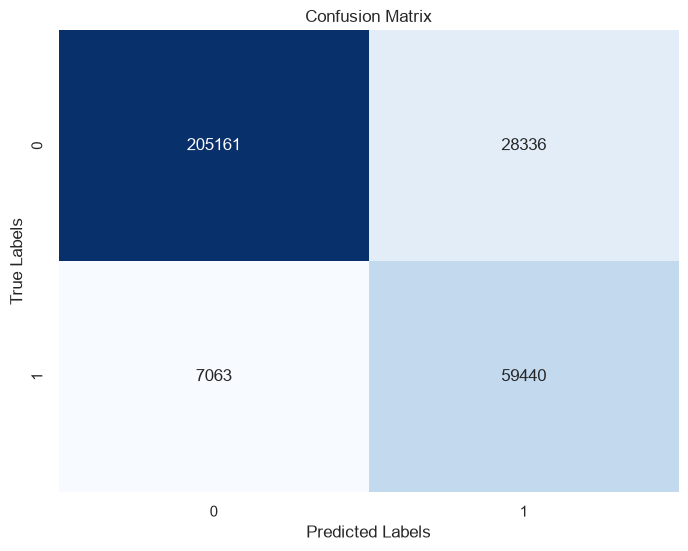

Precision: 0.6771782719650018
Recall: 0.8937942649203795
F1-Score: 0.7705520518022544


In [8]:
# --- Logistic Regression for Classification ---

#Recall improved by adding class_weight='balanced' to handle class imbalance
log_reg = LogisticRegression(max_iter=1000 , class_weight='balanced', random_state=42)


log_reg.fit(X_train, y_class_train)
y_pred_log = log_reg.predict(X_test)

acc_log = accuracy_score(y_class_test, y_pred_log)
print("Logistic Regression Accuracy:", acc_log)

cm =  confusion_matrix(y_class_test, y_pred_log)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()


precision = precision_score(y_class_test, y_pred_log)
recall = recall_score(y_class_test, y_pred_log)
f1 = f1_score(y_class_test, y_pred_log)
##roc_auc = roc_auc_score(y_class_test, y_prob_class)  # Typically y_prob_class[:,1] if using predict_proba

print("Precision:", precision)
print("Recall:", recall)
print("F1-Score:", f1)
#print("ROC-AUC:", roc_auc)


In [9]:
# --- Decision Tree Classifier ---
dt_clf = DecisionTreeClassifier(random_state=50,max_depth=5,class_weight='balanced')
dt_clf.fit(X_train, y_class_train)
y_pred_dt_clf = dt_clf.predict(X_test)

acc_dt_clf = accuracy_score(y_class_test, y_pred_dt_clf)
precision_dt = precision_score(y_class_test, y_pred_dt_clf)
recall_dt = recall_score(y_class_test, y_pred_dt_clf)
f1_dt = f1_score(y_class_test, y_pred_dt_clf)

print("Decision Tree Classifier Accuracy:", acc_dt_clf)
print("Precision:", precision_dt)
print("Recall:", recall_dt)
print("F1-Score:", f1_dt)
print("Confusion Matrix:\n", confusion_matrix(y_class_test, y_pred_dt_clf))

Decision Tree Classifier Accuracy: 0.7556433333333333
Precision: 0.4710295495188623
Recall: 0.8317369141241748
F1-Score: 0.6014472661240778
Confusion Matrix:
 [[171380  62117]
 [ 11190  55313]]


In [10]:
# --- Random Forest Classifier ---
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_clf.fit(X_train, y_class_train)
y_pred_rf_clf = rf_clf.predict(X_test)
acc_rf_clf = accuracy_score(y_class_test, y_pred_rf_clf)
precision_rf_clf = precision_score(y_class_test, y_pred_rf_clf)
recall_rf_clf = recall_score(y_class_test, y_pred_rf_clf)
f1_rf_clf = f1_score(y_class_test, y_pred_rf_clf)

print("Random Forest Classifier Accuracy:", acc_rf_clf)
print("Precision:", precision_rf_clf)
print("Recall:", recall_rf_clf)
print("F1-Score:", f1_rf_clf)
print("Confusion Matrix:\n", confusion_matrix(y_class_test, y_pred_rf_clf))

Random Forest Classifier Accuracy: 0.89379
Precision: 0.7329647862696043
Recall: 0.8194066433093244
F1-Score: 0.7737790115655773
Confusion Matrix:
 [[213644  19853]
 [ 12010  54493]]


In [11]:
# --- KNN Classifier ---

# Since the dataset is large (1M rows), running KNN on the full X_processed/X_train would be too slow, as KNN calculates distance 
# to every training point for each prediction. Thus, a smaller random sample from X_train is used for KNN training.

for sample_size in [50000, 100000, 150000, 200000]:  
    X_train_knn, _, y_train_knn, _ = train_test_split(
        X_train, y_class_train, train_size=sample_size, random_state=42
    )
    
    knn_clf = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
    knn_clf.fit(X_train_knn, y_train_knn)
    y_pred_knn = knn_clf.predict(X_test)
    
    precision_sample = precision_score(y_class_test, y_pred_knn)
    recall_sample = recall_score(y_class_test, y_pred_knn)
    f1_sample = f1_score(y_class_test, y_pred_knn)
    print(f"Sample size: {sample_size} | Precision: {precision_sample:.4f} | Recall: {recall_sample:.4f} | F1: {f1_sample:.4f}")

Sample size: 50000 | Precision: 0.7868 | Recall: 0.6906 | F1: 0.7356
Sample size: 100000 | Precision: 0.7866 | Recall: 0.7059 | F1: 0.7441
Sample size: 150000 | Precision: 0.7848 | Recall: 0.7105 | F1: 0.7458
Sample size: 200000 | Precision: 0.7852 | Recall: 0.7120 | F1: 0.7468


KNN Accuracy: 0.8923466666666666


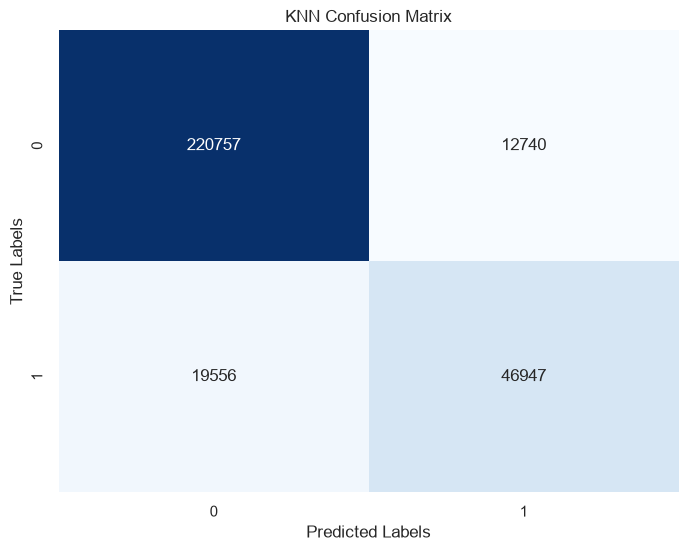

Precision: 0.7865531857858495
Recall: 0.7059380779814445
F1-Score: 0.7440684681828988


In [9]:
X_train_knn, _, y_train_knn, _ = train_test_split(
    X_train, y_class_train, train_size=100000, random_state=42
)

knn_clf = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn_clf.fit(X_train_knn, y_train_knn)
y_pred_knn = knn_clf.predict(X_test)

acc_knn = accuracy_score(y_class_test, y_pred_knn)
print("KNN Accuracy:", acc_knn)

cm_knn = confusion_matrix(y_class_test, y_pred_knn)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("KNN Confusion Matrix")
plt.show()

precision_knn = precision_score(y_class_test, y_pred_knn)
recall_knn = recall_score(y_class_test, y_pred_knn)
f1_knn = f1_score(y_class_test, y_pred_knn)

print("Precision:", precision_knn)
print("Recall:", recall_knn)
print("F1-Score:", f1_knn)

In [34]:
for k in [1, 3, 5, 7, 9]:
    knn_clf = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    knn_clf.fit(X_train_knn, y_train_knn)
    y_pred_knn = knn_clf.predict(X_test)

    precision_knn = precision_score(y_class_test, y_pred_knn)
    recall_knn = recall_score(y_class_test, y_pred_knn)
    f1_knn = f1_score(y_class_test, y_pred_knn) 

    print(f"k={k} | Precision: {precision_knn:.4f} | Recall: {recall_knn:.4f} | F1: {f1_knn:.4f}")

k=1 | Precision: 0.7008 | Recall: 0.6898 | F1: 0.6953
k=3 | Precision: 0.7608 | Recall: 0.7017 | F1: 0.7301
k=5 | Precision: 0.7865 | Recall: 0.7059 | F1: 0.7441
k=7 | Precision: 0.7983 | Recall: 0.7054 | F1: 0.7490
k=9 | Precision: 0.8074 | Recall: 0.7028 | F1: 0.7515


SVM (balanced) Accuracy: 0.8729133333333333


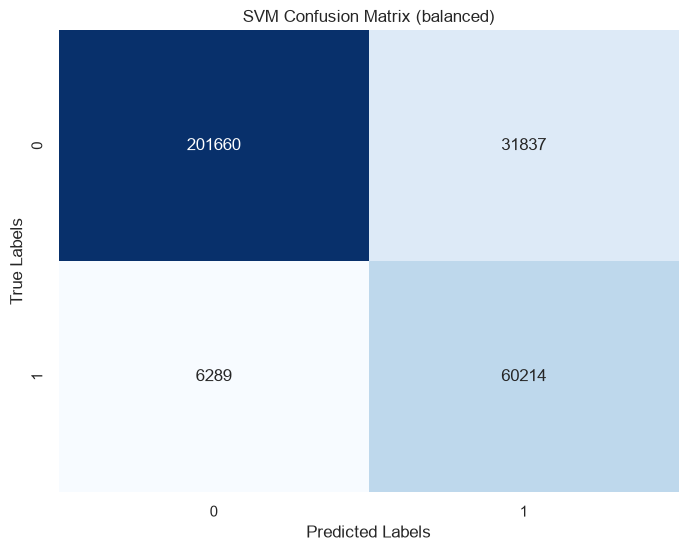

Precision: 0.6541373803652323
Recall: 0.9054328376163482
F1-Score: 0.7595393367559318


In [7]:
# --- SVM Classifier ---

X_train_svm, _, y_train_svm, _ = train_test_split(
    X_train, y_class_train, train_size=50000, random_state=42
)

svm_clf_balanced = SVC(kernel='rbf', random_state=42, class_weight='balanced')
svm_clf_balanced.fit(X_train_svm, y_train_svm)
y_pred_svm_balanced = svm_clf_balanced.predict(X_test)

acc_svm_balanced = accuracy_score(y_class_test, y_pred_svm_balanced)
print("SVM (balanced) Accuracy:", acc_svm_balanced)

cm_svm_balanced = confusion_matrix(y_class_test, y_pred_svm_balanced)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm_balanced, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("SVM Confusion Matrix (balanced)")
plt.show()

precision_svm_balanced = precision_score(y_class_test, y_pred_svm_balanced)
recall_svm_balanced = recall_score(y_class_test, y_pred_svm_balanced)
f1_svm_balanced = f1_score(y_class_test, y_pred_svm_balanced)

print("Precision:", precision_svm_balanced)
print("Recall:", recall_svm_balanced)
print("F1-Score:", f1_svm_balanced)

### C. Interpreting Results

#### Log Odds for Logistic Regression

In [13]:
log_odds = log_reg.coef_  # This returns a 2D array (for binary classification, shape is (1, n_features))
log_odds_series = pd.Series(log_odds[0], index=X_train.columns)
print("Logistic Regression Log Odds:")
print(log_odds_series.sort_values(ascending=False))

Logistic Regression Log Odds:
payment_required                  5.838521
fake_certificate_offer            3.875531
phishing_language_score           2.692891
vague_description_score           2.224547
urgency_score                     1.299859
keyword_spam_score                1.051318
grammatical_errors                0.824530
suspicious_email_domain           0.209595
recruiter_email_type_Free         0.209595
recruiter_email_type_Corporate   -2.515098
linkedin_presence                -2.929696
website_available                -2.942851
dtype: float64


The sign and magnitude of each log-odds coefficient indicate how a one-unit change in the feature affects the log odds of being in the positive class.

#### Visualizing a Decision Tree

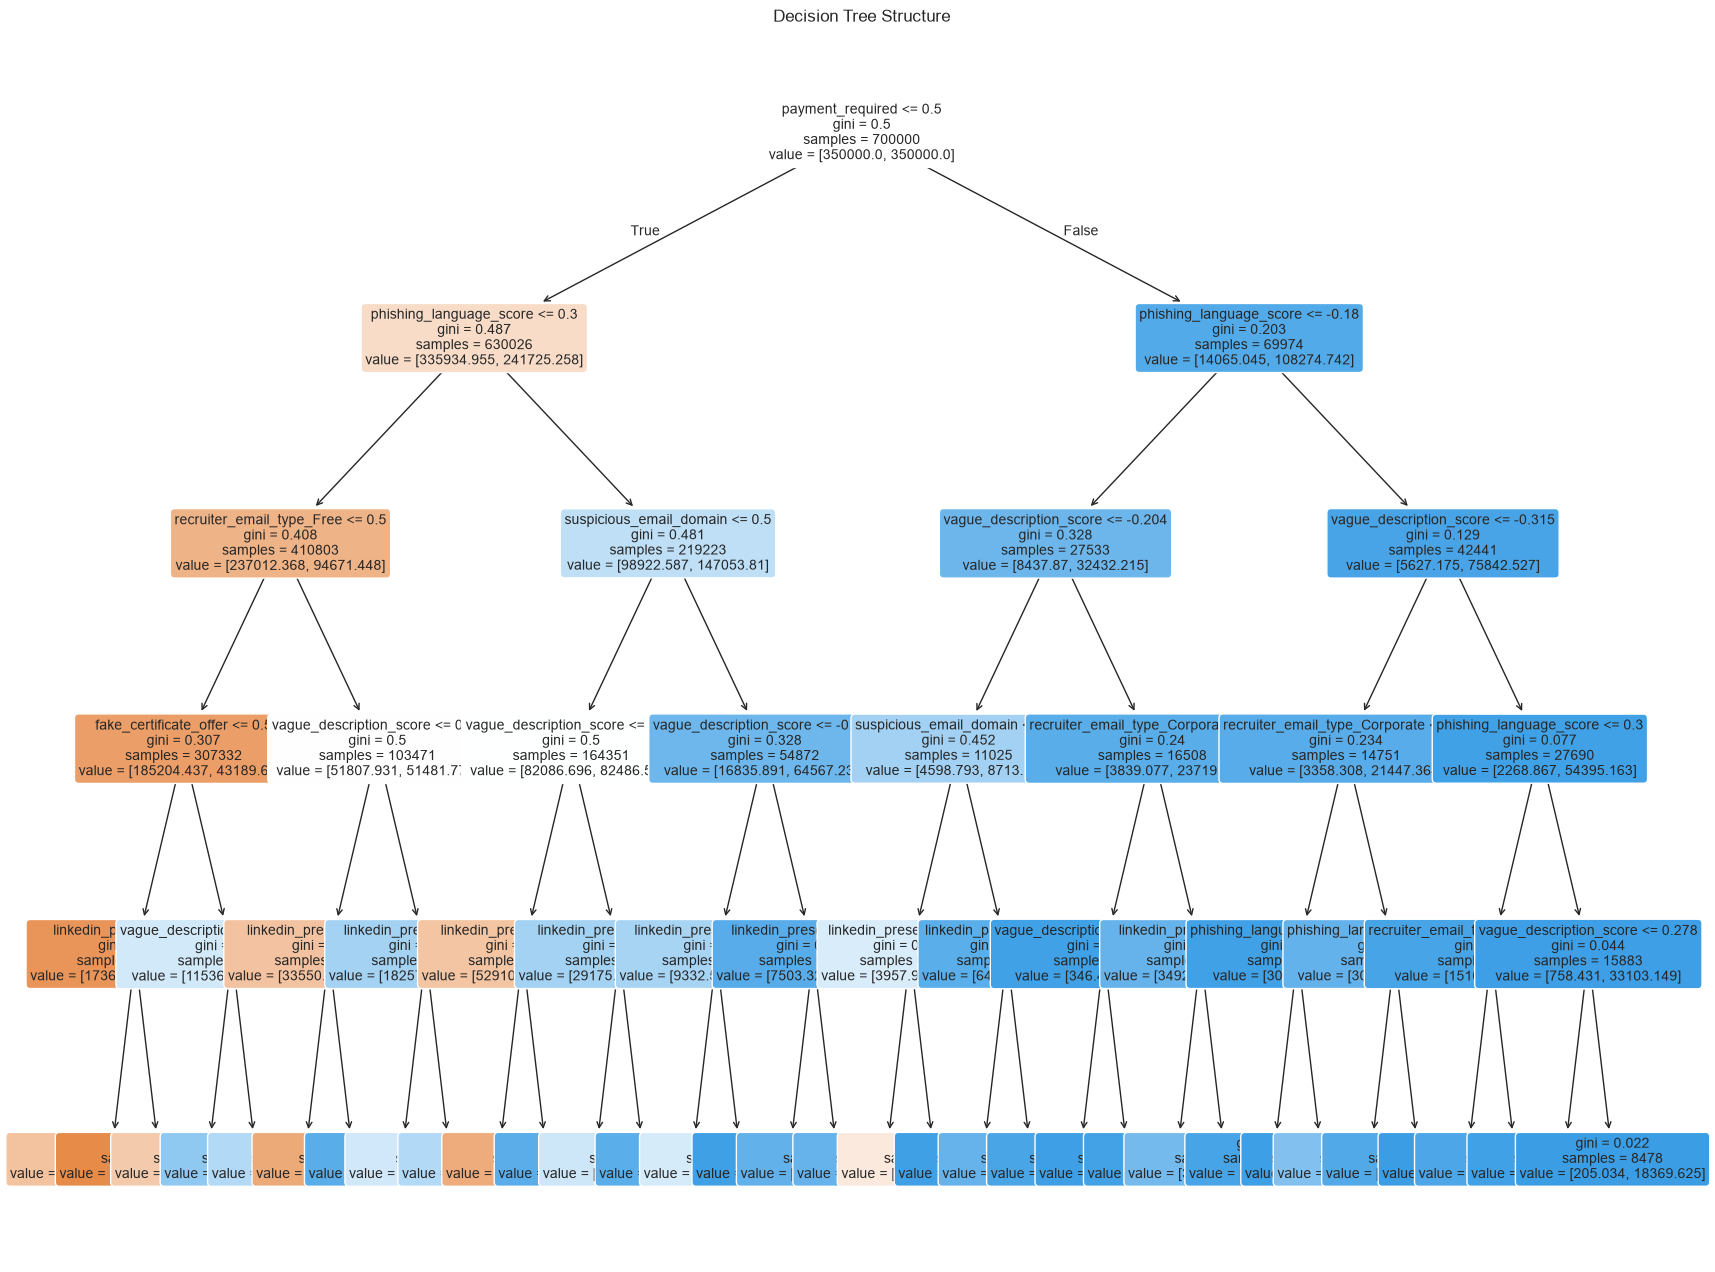

In [14]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 16))
plot_tree(dt_clf, feature_names=X_train.columns, filled=True, rounded=True, fontsize=10)
plt.title("Decision Tree Structure")
plt.show()

I personally find this fascinating to look at. You can directly see how the tree will look at an observation and make a decision about which class it should put that in.

The trees get harder to look at the more you increase the max_depth hyperparameter, so its a balancing act between model performance and interpretability.

#### Hyperparameter Tuning 

We will use Grid Search CV that has cross-validation built in and will help us compare model performance across different hyperparameters to choose the best one.

It would be really productive if you try to understand what the hyperparameters mean and how they will be helpful for your problem and make educated guesses about which ones to test with gridSearch. 

In [15]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid. You can play around with different grids or make a giant one with a lot of numbers.

param_grid = {
    'criterion': ['gini', 'entropy'],  # Splitting criteria
    'max_depth': [None, 5, 10, 20],      # Maximum depth of the tree
    'min_samples_split': [2, 5, 10],     # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2, 4],       # Minimum number of samples required to be at a leaf node
    'max_features': [None, 'sqrt', 'log2']  # Number of features to consider when looking for the best split
}


# Assume rf_reg is your RandomForestRegressor instance
grid_search = GridSearchCV(estimator= dt_clf, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_class_train)


print("Best Hyperparameters:", grid_search.best_params_)
print("Best Cross-Validated accuracy:", grid_search.best_score_)

Best Hyperparameters: {'criterion': 'entropy', 'max_depth': None, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best Cross-Validated accuracy: 0.86486


In [13]:
results_df = pd.DataFrame(grid_search.cv_results_)

# Display selected columns, e.g., parameters and mean test score
results_df[['params', 'mean_test_score', 'std_test_score']]

,params,mean_test_score,std_test_score
0,"{'criterion': 'gini', 'max_depth': None, 'max_...",0.861471,0.001041
1,"{'criterion': 'gini', 'max_depth': None, 'max_...",0.866584,0.001127
2,"{'criterion': 'gini', 'max_depth': None, 'max_...",0.873776,0.001049
3,"{'criterion': 'gini', 'max_depth': None, 'max_...",0.869503,0.001049
4,"{'criterion': 'gini', 'max_depth': None, 'max_...",0.870146,0.001084
...,...,...,...
211,"{'criterion': 'entropy', 'max_depth': 20, 'max...",0.877969,0.001041
212,"{'criterion': 'entropy', 'max_depth': 20, 'max...",0.880423,0.001523
213,"{'criterion': 'entropy', 'max_depth': 20, 'max...",0.882041,0.000266
214,"{'criterion': 'entropy', 'max_depth': 20, 'max...",0.882041,0.000266
